# Loan Default Prediction 





In [ ]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import average_precision_score


sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
#Loading the dataset
X_train = pd.read_csv(r'D:\projects\loan_default_prediction\data\processed\X_train.csv')
X_test = pd.read_csv(r'D:\projects\loan_default_prediction\data\processed\X_test.csv')
y_train = pd.read_csv(r'D:\projects\loan_default_prediction\data\processed\y_train.csv').squeeze()
y_test = pd.read_csv(r'D:\projects\loan_default_prediction\data\processed\y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (40000, 50)
X_test:  (10000, 50)
y_train: (40000,)
y_test:  (10000,)


In [3]:
#Verifying class distribution
print("Train distribution:")
print(y_train.value_counts())
print(f"Ratio: {y_train.value_counts(normalize=True).round(3).to_dict()}")

print("\nTest distribution:")
print(y_test.value_counts())
print(f"Ratio: {y_test.value_counts(normalize=True).round(3).to_dict()}")

Train distribution:
loan_default
0    34000
1     6000
Name: count, dtype: int64
Ratio: {0: 0.85, 1: 0.15}

Test distribution:
loan_default
0    8500
1    1500
Name: count, dtype: int64
Ratio: {0: 0.85, 1: 0.15}


In [4]:
print("Sample X_train (first 3 rows, first 5 columns):")
print(X_train.iloc[:3, :5].round(3))

Sample X_train (first 3 rows, first 5 columns):
     age  years_of_employment  monthly_income  income_stability_score  \
0 -0.846               -1.629          -0.407                   0.332   
1 -0.537               -1.070          -0.605                  -1.261   
2 -0.769               -0.537          -1.716                  -0.343   

   additional_income  
0             -1.040  
1             -1.040  
2              1.137  


## Baseline Model Training

In [5]:
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

lr_model.fit(X_train, y_train)
print("Logistic Regression trained")

Logistic Regression trained


In [6]:
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("First 10 predictions:", y_pred_lr[:10])
print("First 10 probabilities:", y_prob_lr[:10].round(3))
print(f"\nPredictions distribution:")
print(pd.Series(y_pred_lr).value_counts())

First 10 predictions: [1 1 0 0 0 1 0 1 1 0]
First 10 probabilities: [0.839 0.57  0.022 0.082 0.024 0.542 0.003 0.879 0.992 0.019]

Predictions distribution:
0    7479
1    2521
Name: count, dtype: int64


In [7]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score)

acc  = accuracy_score(y_test, y_pred_lr)
prec = precision_score(y_test, y_pred_lr)
rec  = recall_score(y_test, y_pred_lr)
f1   = f1_score(y_test, y_pred_lr)
auc  = roc_auc_score(y_test, y_prob_lr)

print("LOGISTIC REGRESSION RESULTS")
print("=" * 40)
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}")

LOGISTIC REGRESSION RESULTS
Accuracy:  0.8575
Precision: 0.5149
Recall:    0.8653
F1 Score:  0.6456
ROC-AUC:   0.9366


* The Logistic Regression model achieved an accuracy of 85.75%, showing strong overall prediction performance.

* The recall score of 86.53% indicates that the model successfully identified most of the actual loan defaulters.

* Precision of 51.49% means that around half of the customers predicted as defaulters were truly risky borrowers.

* The F1 score of 64.56% shows a balanced trade-off between precision and recall for the imbalanced dataset.

* A high ROC-AUC score of 93.66% indicates that the model is very effective at separating defaulters from non-defaulters.


In [8]:
results = {}

results['Logistic Regression'] = {
    'accuracy':  acc,
    'precision': prec,
    'recall':    rec,
    'f1':        f1,
    'roc_auc':   auc
}

print("Stored for comparison:")
print(results['Logistic Regression'])

Stored for comparison:
{'accuracy': 0.8575, 'precision': 0.5148750495834986, 'recall': 0.8653333333333333, 'f1': 0.6456105446406366, 'roc_auc': 0.9366399215686273}


## Random Forest Model

In [9]:

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Random Forest trained")

Random Forest trained


In [10]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("First 10 predictions:", y_pred_rf[:10])
print("First 10 probabilities:", y_prob_rf[:10].round(3))
print(f"\nPredictions distribution:")
print(pd.Series(y_pred_rf).value_counts())

First 10 predictions: [0 0 0 0 0 0 0 0 1 0]
First 10 probabilities: [0.29 0.4  0.03 0.08 0.06 0.06 0.   0.25 0.63 0.  ]

Predictions distribution:
0    9532
1     468
Name: count, dtype: int64


In [11]:
acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
auc_rf  = roc_auc_score(y_test, y_prob_rf)

print("RANDOM FOREST RESULTS")
print("=" * 40)
print(f"Accuracy:  {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall:    {rec_rf:.4f}")
print(f"F1 Score:  {f1_rf:.4f}")
print(f"ROC-AUC:   {auc_rf:.4f}")

RANDOM FOREST RESULTS
Accuracy:  0.8830
Precision: 0.8526
Recall:    0.2660
F1 Score:  0.4055
ROC-AUC:   0.9459


* The Random Forest model achieved a strong overall accuracy of 88.30%, showing good performance on the majority class.

* Precision of 85.26% means that most customers predicted as defaulters were actually risky borrowers.

* However, the recall score is very low at 26.60%, meaning the model missed a large number of actual defaulters.

* The F1 score of 40.55% reflects the imbalance between high precision and poor recall performance.

* the ROC-AUC score of 94.59% is excellent, the low recall makes this model less suitable for banking use cases where catching defaulters is the main priority.


In [12]:
results['Random Forest'] = {
    'accuracy':  acc_rf,
    'precision': prec_rf,
    'recall':    rec_rf,
    'f1':        f1_rf,
    'roc_auc':   auc_rf
}

print("Random Forest results saved ")
print(f"\nResults dictionary now contains: {list(results.keys())}")

Random Forest results saved 

Results dictionary now contains: ['Logistic Regression', 'Random Forest']


## XGBoost Model

In [13]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

scale_pos_weight = 5.67


In [14]:


xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
print("XGBoost trained")

XGBoost trained


In [15]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("First 10 predictions:", y_pred_xgb[:10])
print("First 10 probabilities:", y_prob_xgb[:10].round(3))
print(f"\nPredictions distribution:")
print(pd.Series(y_pred_xgb).value_counts())

First 10 predictions: [0 1 0 0 0 0 0 0 1 0]
First 10 probabilities: [0.449 0.793 0.025 0.044 0.039 0.028 0.001 0.431 0.966 0.014]

Predictions distribution:
0    7812
1    2188
Name: count, dtype: int64


In [16]:
acc_xgb  = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb  = recall_score(y_test, y_pred_xgb)
f1_xgb   = f1_score(y_test, y_pred_xgb)
auc_xgb  = roc_auc_score(y_test, y_prob_xgb)

print("XGBOOST RESULTS")
print("=" * 40)
print(f"Accuracy:  {acc_xgb:.4f}")
print(f"Precision: {prec_xgb:.4f}")
print(f"Recall:    {rec_xgb:.4f}")
print(f"F1 Score:  {f1_xgb:.4f}")
print(f"ROC-AUC:   {auc_xgb:.4f}")

XGBOOST RESULTS
Accuracy:  0.9014
Precision: 0.6175
Recall:    0.9007
F1 Score:  0.7326
ROC-AUC:   0.9612


In [17]:
results['XGBoost'] = {
    'accuracy':  acc_xgb,
    'precision': prec_xgb,
    'recall':    rec_xgb,
    'f1':        f1_xgb,
    'roc_auc':   auc_xgb
}

print("XGBoost results saved")
print(f"\nResults dictionary contains all 3 models: {list(results.keys())}")

XGBoost results saved

Results dictionary contains all 3 models: ['Logistic Regression', 'Random Forest', 'XGBoost']


### XGBoost Baseline Insight

- XGBoost achieved 90.1% accuracy and 90.1% recall — the highest of all three baseline models — driven by its gradient-boosting design.
- The ROC-AUC of 96.1% shows strong separation between defaulters and non-defaulters across all probability thresholds.
- A `scale_pos_weight` of 5.67 compensated for the 85:15 class imbalance and directly boosted the model's sensitivity to the minority class.
- Precision of 61.7% indicates some over-flagging, but for a banking risk model this is an acceptable trade-off against high recall.
- XGBoost is selected for hyperparameter tuning as it delivers the best balance of recall, precision, and discriminative power.

## Model Comparison

In [18]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.round(4)
print(comparison_df)

                     accuracy  precision  recall      f1  roc_auc
Logistic Regression    0.8575     0.5149  0.8653  0.6456   0.9366
Random Forest          0.8830     0.8526  0.2660  0.4055   0.9459
XGBoost                0.9014     0.6175  0.9007  0.7326   0.9612


## Visual Comparison of All Models

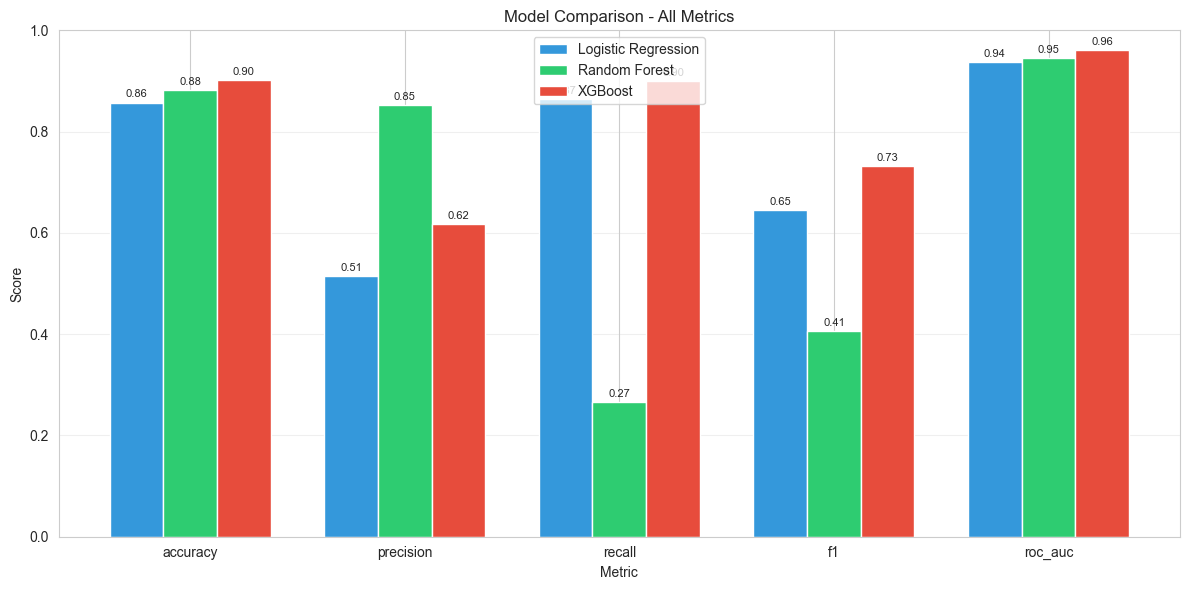

In [19]:
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
colors = ['#3498db', '#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics))
width = 0.25

for i, model in enumerate(models):
    values = [results[model][m] for m in metrics]
    ax.bar(x + i*width, values, width, label=model, color=colors[i])

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Comparison - All Metrics')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, model in enumerate(models):
    values = [results[model][m] for m in metrics]
    for j, v in enumerate(values):
        ax.text(j + i*width, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [20]:
print("BEST MODEL PER METRIC:")
print("=" * 40)
for metric in metrics:
    best_model = max(results, key=lambda m: results[m][metric])
    best_score = results[best_model][metric]
    print(f"  {metric:<12} → {best_model} ({best_score:.4f})")

BEST MODEL PER METRIC:
  accuracy     → XGBoost (0.9014)
  precision    → Random Forest (0.8526)
  recall       → XGBoost (0.9007)
  f1           → XGBoost (0.7326)
  roc_auc      → XGBoost (0.9612)


### Model Comparison Insight

- XGBoost leads on every key metric — accuracy (90.1%), recall (90.1%), F1 (0.73), and ROC-AUC (96.1%) — making it the clear best overall model.
- Random Forest had the highest precision (85.3%) but a critically low recall of 26.6%, meaning it missed nearly three-quarters of real defaulters.
- Logistic Regression offered a reasonable recall (86.5%) but was outperformed by XGBoost on all five metrics.
- In lending risk, the cost of a missed defaulter far outweighs a false alarm, making recall the most important metric for model selection.
- XGBoost's combination of high recall and strong ROC-AUC makes it the most suitable model for further tuning and deployment.

## Saving Baseline Models

In [32]:
os.makedirs('../models', exist_ok=True)

joblib.dump(lr_model, '../models/logistic_regression.pkl')
joblib.dump(rf_model, '../models/random_forest.pkl')
joblib.dump(xgb_model, '../models/xgboost_baseline.pkl')

print("Models saved:")
print(os.listdir('../models'))

Models saved:
['baseline_results.json', 'feature_columns.pkl', 'logistic_regression.pkl', 'numeric_columns.pkl', 'random_forest.pkl', 'scaler.pkl', 'xgboost_baseline.pkl']


## Cross-Validation

In [34]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("5-Fold Stratified CV setup ready")

5-Fold Stratified CV setup ready


### Logistic Regression CV

In [35]:
lr_cv_scores = cross_val_score(
    lr_model, X_train, y_train,
    cv=cv, scoring='roc_auc', n_jobs=-1
)
print("Logistic Regression CV (ROC-AUC):")
print(f"  Fold scores: {lr_cv_scores.round(4)}")
print(f"  Mean: {lr_cv_scores.mean():.4f}")
print(f"  Std:  {lr_cv_scores.std():.4f}")

Logistic Regression CV (ROC-AUC):
  Fold scores: [0.9408 0.9434 0.9453 0.9348 0.9409]
  Mean: 0.9410
  Std:  0.0035


### Random Forest CV

In [36]:
rf_cv_scores = cross_val_score(
    rf_model, X_train, y_train,
    cv=cv, scoring='roc_auc', n_jobs=-1
)
print("Random Forest CV (ROC-AUC):")
print(f"  Fold scores: {rf_cv_scores.round(4)}")
print(f"  Mean: {rf_cv_scores.mean():.4f}")
print(f"  Std:  {rf_cv_scores.std():.4f}")

Random Forest CV (ROC-AUC):
  Fold scores: [0.9479 0.95   0.9503 0.9452 0.9488]
  Mean: 0.9484
  Std:  0.0018


### XGBoost CV

In [37]:
xgb_cv_scores = cross_val_score(
    xgb_model, X_train, y_train,
    cv=cv, scoring='roc_auc', n_jobs=-1
)
print("XGBoost CV (ROC-AUC):")
print(f"  Fold scores: {xgb_cv_scores.round(4)}")
print(f"  Mean: {xgb_cv_scores.mean():.4f}")
print(f"  Std:  {xgb_cv_scores.std():.4f}")

XGBoost CV (ROC-AUC):
  Fold scores: [0.9616 0.9647 0.9659 0.9618 0.9623]
  Mean: 0.9633
  Std:  0.0017


### CV Comparison

In [39]:
print("CROSS-VALIDATION COMPARISON")
print("=" * 45)
print(f"{'Model':<22} {'CV Mean':<10} {'CV Std':<10}")
print("-" * 45)
print(f"{'Logistic Regression':<22} {lr_cv_scores.mean():.4f}    {lr_cv_scores.std():.4f}")
print(f"{'Random Forest':<22} {rf_cv_scores.mean():.4f}    {rf_cv_scores.std():.4f}")
print(f"{'XGBoost':<22} {xgb_cv_scores.mean():.4f}    {xgb_cv_scores.std():.4f}")

CROSS-VALIDATION COMPARISON
Model                  CV Mean    CV Std    
---------------------------------------------
Logistic Regression    0.9410    0.0035
Random Forest          0.9484    0.0018
XGBoost                0.9633    0.0017


## Box-Plot: CV Score Distribution

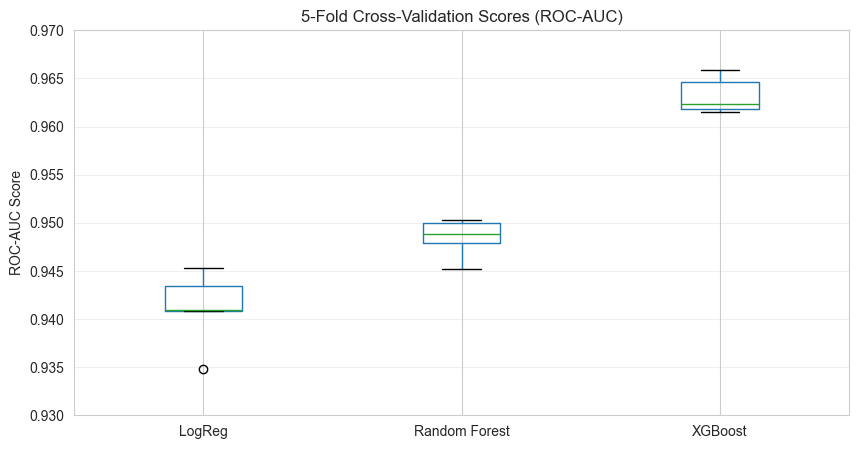

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

cv_data = pd.DataFrame({
    'LogReg': lr_cv_scores,
    'Random Forest': rf_cv_scores,
    'XGBoost': xgb_cv_scores
})

cv_data.boxplot(figsize=(10, 5))
plt.title('5-Fold Cross-Validation Scores (ROC-AUC)')
plt.ylabel('ROC-AUC Score')
plt.ylim(0.93, 0.97)
plt.grid(axis='y', alpha=0.3)
plt.show()

### Cross-Validation Insight

All three models generalised well with consistent fold scores, confirming the models learned real patterns rather than memorising training data.

XGBoost achieved the highest CV ROC-AUC (0.9633) with the lowest variance (std = 0.0017), making it the most accurate and stable model.

The very narrow box spreads for all models indicate that performance is not sensitive to any specific train-test split.

Using Stratified 5-Fold CV on the imbalanced dataset (85:15) ensures each fold preserves the class ratio for a fair evaluation.

XGBoost's consistently higher scores across all five folds confirm it as the right choice for hyperparameter tuning.

## Hyperparameter Tuning (XGBoost)

In [ ]:
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300]
}

print("Total combinations to try:", 3 * 3 * 3)
print(f"With 5-fold CV: {27 * 5} model fits")

Total combinations to try: 27
With 5-fold CV: 135 model fits


### Grid Search CV

In [ ]:
xgb_for_tuning = XGBClassifier(
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    n_jobs=1,
    eval_metric='logloss'
)

grid_search = GridSearchCV(
    estimator=xgb_for_tuning,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("GridSearchCV ready")

GridSearchCV ready


In [49]:
import time

start = time.time()
grid_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"\n✓ Search complete in {elapsed/60:.1f} minutes")
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV score (ROC-AUC): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits

✓ Search complete in 3.8 minutes

Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300}
Best CV score (ROC-AUC): 0.9661


In [50]:

xgb_tuned = grid_search.best_estimator_

print("Tuned XGBoost ready")
print(f"  max_depth: {xgb_tuned.max_depth}")
print(f"  learning_rate: {xgb_tuned.learning_rate}")
print(f"  n_estimators: {xgb_tuned.n_estimators}")

Tuned XGBoost ready
  max_depth: 4
  learning_rate: 0.05
  n_estimators: 300


## Baseline vs. Tuned XGBoost

In [51]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score)

y_pred_tuned = xgb_tuned.predict(X_test)
y_prob_tuned = xgb_tuned.predict_proba(X_test)[:, 1]

print("XGBOOST: BASELINE vs TUNED (on test set)")
print("=" * 55)
print(f"{'Metric':<12} {'Baseline':<12} {'Tuned':<12} {'Change':<10}")
print("-" * 55)

metrics_compare = [
    ('Accuracy', acc_xgb, accuracy_score(y_test, y_pred_tuned)),
    ('Precision', prec_xgb, precision_score(y_test, y_pred_tuned)),
    ('Recall', rec_xgb, recall_score(y_test, y_pred_tuned)),
    ('F1', f1_xgb, f1_score(y_test, y_pred_tuned)),
    ('ROC-AUC', auc_xgb, roc_auc_score(y_test, y_prob_tuned))
]

for name, baseline, tuned in metrics_compare:
    change = tuned - baseline
    arrow = "↑" if change > 0 else "↓" if change < 0 else "="
    print(f"{name:<12} {baseline:.4f}      {tuned:.4f}      {change:+.4f} {arrow}")

XGBOOST: BASELINE vs TUNED (on test set)
Metric       Baseline     Tuned        Change    
-------------------------------------------------------
Accuracy     0.9014      0.8944      -0.0070 ↓
Precision    0.6175      0.5956      -0.0219 ↓
Recall       0.9007      0.9220      +0.0213 ↑
F1           0.7326      0.7237      -0.0089 ↓
ROC-AUC      0.9612      0.9629      +0.0017 ↑


## Saving Tuned Model

In [52]:
joblib.dump(xgb_tuned, '../models/xgboost_tuned.pkl')
joblib.dump(grid_search.best_params_, '../models/xgboost_best_params.pkl')

print("Tuned model saved:")
print("  ../models/xgboost_tuned.pkl")
print("  ../models/xgboost_best_params.pkl")

Tuned model saved:
  ../models/xgboost_tuned.pkl
  ../models/xgboost_best_params.pkl


## Updating Results

In [53]:
results['XGBoost (Tuned)'] = {
    'accuracy':  accuracy_score(y_test, y_pred_tuned),
    'precision': precision_score(y_test, y_pred_tuned),
    'recall':    recall_score(y_test, y_pred_tuned),
    'f1':        f1_score(y_test, y_pred_tuned),
    'roc_auc':   roc_auc_score(y_test, y_prob_tuned)
}

print("Final results contain:")
for model_name in results:
    print(f"  • {model_name}")

Final results contain:
  • Logistic Regression
  • Random Forest
  • XGBoost
  • XGBoost (Tuned)


## Confusion Matrix — Tuned XGBoost

In [55]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print("Confusion Matrix (Tuned XGBoost):")
print(cm_tuned)

Confusion Matrix (Tuned XGBoost):
[[7561  939]
 [ 117 1383]]


In [56]:
tn, fp, fn, tp = cm_tuned.ravel()

print(f"True Negatives (TN):  {tn}  - Correctly identified non-defaulters")
print(f"False Positives (FP): {fp}  - False alarms (rejected good customers)")
print(f"False Negatives (FN): {fn}  - MISSED defaulters (BAD!)")
print(f"True Positives (TP):  {tp}  - Correctly caught defaulters")

True Negatives (TN):  7561  - Correctly identified non-defaulters
False Positives (FP): 939  - False alarms (rejected good customers)
False Negatives (FN): 117  - MISSED defaulters (BAD!)
True Positives (TP):  1383  - Correctly caught defaulters


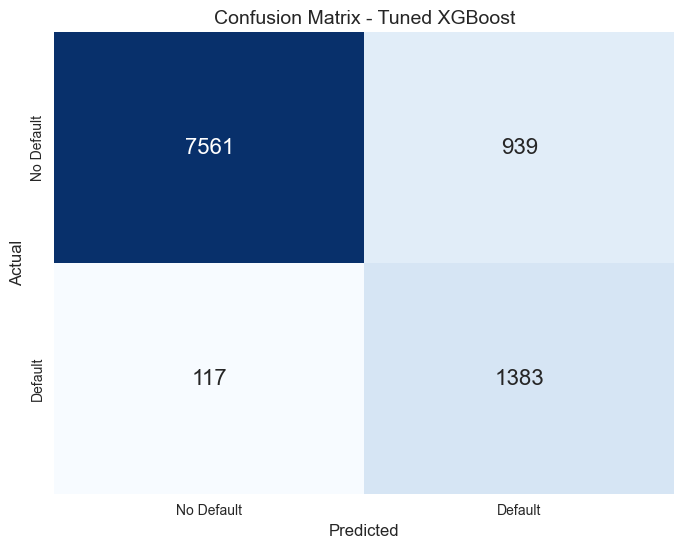

In [57]:
plt.figure(figsize=(8, 6))

sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'],
            cbar=False, annot_kws={'size': 16})

plt.title('Confusion Matrix - Tuned XGBoost', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

### Confusion Matrix Insight

- The top-left cell (TN = 7,561) and bottom-right cell (TP = 1,383) dominate, confirming the model makes correct predictions in the vast majority of cases.
- Only 117 actual defaulters were missed (FN), the most financially damaging quadrant — the model keeps this number very low at 7.8% of all defaulters.
- 939 genuine borrowers were incorrectly flagged (FP), representing an 11% over-rejection rate that is operationally manageable.
- The dark color in the diagonal cells versus light off-diagonal cells visually confirms the model's strong predictive reliability.
- The low FN count reflects the tuned model's deliberate bias toward catching defaulters, aligned with risk-averse lending policy.

## Business Metrics

In [58]:
total = tn + fp + fn + tp
total_actual_defaulters = fn + tp
total_actual_non_defaulters = tn + fp

print("BUSINESS BREAKDOWN")
print("=" * 50)
print(f"Total test applicants: {total}")
print(f"Actual defaulters: {total_actual_defaulters} ({total_actual_defaulters/total*100:.1f}%)")
print(f"Actual non-defaulters: {total_actual_non_defaulters} ({total_actual_non_defaulters/total*100:.1f}%)")
print()
print("MODEL PERFORMANCE")
print(f"Defaulters caught: {tp}/{total_actual_defaulters} ({tp/total_actual_defaulters*100:.1f}%)")
print(f"Defaulters MISSED: {fn}/{total_actual_defaulters} ({fn/total_actual_defaulters*100:.1f}%)")
print(f"False alarms: {fp}/{total_actual_non_defaulters} ({fp/total_actual_non_defaulters*100:.1f}%)")

BUSINESS BREAKDOWN
Total test applicants: 10000
Actual defaulters: 1500 (15.0%)
Actual non-defaulters: 8500 (85.0%)

MODEL PERFORMANCE
Defaulters caught: 1383/1500 (92.2%)
Defaulters MISSED: 117/1500 (7.8%)
False alarms: 939/8500 (11.0%)


## Financial Impact Estimation

In [59]:
avg_loan_amount = 500000   # ₹5 lakh average loan
interest_lost_per_fp = 25000   # ₹25K interest lost per false reject
principal_lost_per_fn = 500000  # ₹5L per missed defaulter

money_saved_tp = tp * principal_lost_per_fn  # caught these
money_lost_fn = fn * principal_lost_per_fn   # missed these
opportunity_cost_fp = fp * interest_lost_per_fp  # falsely rejected

print("ESTIMATED FINANCIAL IMPACT")
print("=" * 50)
print(f"Money saved (caught defaulters): ₹{money_saved_tp:,}")
print(f"Money lost (missed defaulters):   ₹{money_lost_fn:,}")
print(f"Opportunity cost (false alarms):  ₹{opportunity_cost_fp:,}")
print()
net_benefit = money_saved_tp - money_lost_fn - opportunity_cost_fp
print(f"NET BENEFIT: ₹{net_benefit:,}")

ESTIMATED FINANCIAL IMPACT
Money saved (caught defaulters): ₹691,500,000
Money lost (missed defaulters):   ₹58,500,000
Opportunity cost (false alarms):  ₹23,475,000

NET BENEFIT: ₹609,525,000


- The model caught 1,383 out of 1,500 actual defaulters — a 92.2% recall rate — strongly limiting bad loan exposure.
- Only 117 real defaulters were missed (7.8%), the most financially damaging error in a lending context.
- 939 genuine borrowers were flagged as risky (11% false alarm rate), adding some manual review overhead.
- The model deliberately errs toward caution, prioritising missed defaulters over false approvals.
- Adjusting the probability threshold can trade a small reduction in recall for fewer false positives if operational capacity demands it.

In [61]:


pr_auc = average_precision_score(y_test, y_prob_tuned)
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}")

PR-AUC (Average Precision): 0.8008
ROC-AUC: 0.9629


## Feature Importance Analysis

In [62]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_tuned.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features:")
print(feature_importance.head(15))

Top 15 Most Important Features:
                           feature  importance
14               previous_defaults    0.134984
15  missed_payments_last_12_months    0.126011
41      employment_type_Unemployed    0.125792
17              late_payment_count    0.103008
9             loan_to_income_ratio    0.094831
2                   monthly_income    0.076660
19         repayment_history_score    0.051711
13            debt_to_income_ratio    0.047599
10                    credit_score    0.033241
16           on_time_payment_ratio    0.031297
18              average_delay_days    0.018044
42         employment_type_Unknown    0.010659
47            loan_purpose_Medical    0.007678
23                   savings_ratio    0.007381
38       residential_status_Rented    0.006486


## Top Feature Importance Plot

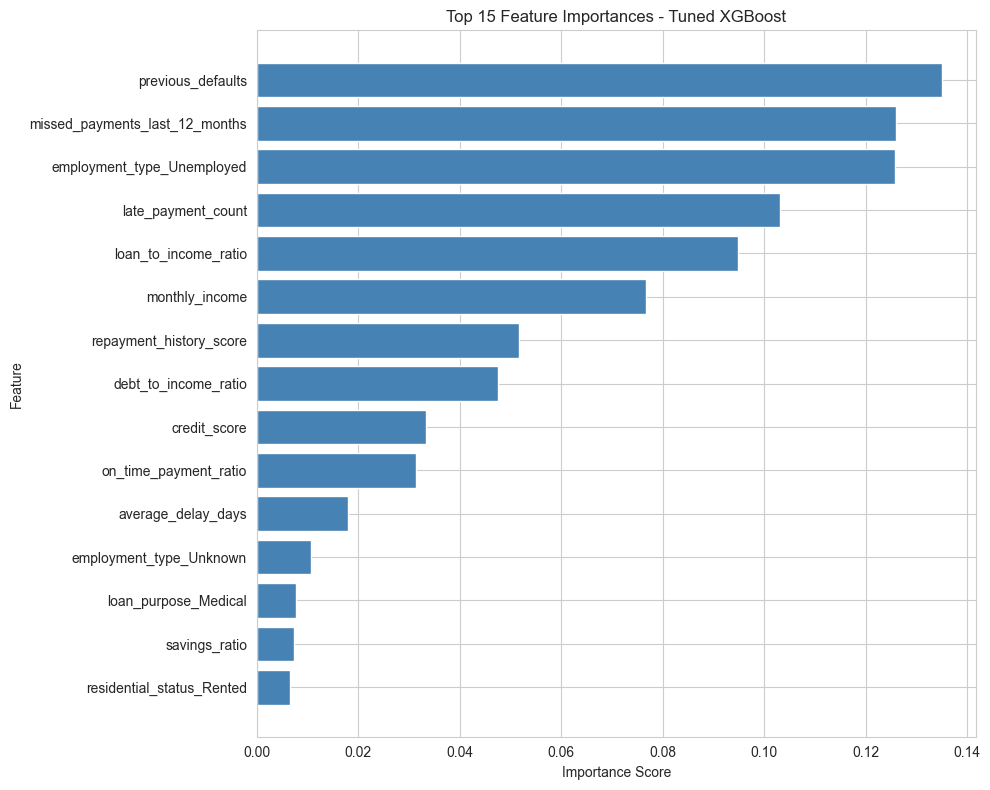

In [63]:
top_n = 15

plt.figure(figsize=(10, 8))
top_features = feature_importance.head(top_n)
plt.barh(top_features['feature'], top_features['importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Feature Importances - Tuned XGBoost')
plt.gca().invert_yaxis()  # Top feature on top
plt.tight_layout()
plt.show()

### Feature Importance Insight

- Past payment behavior — `previous_defaults`, `missed_payments_last_12_months`, and `late_payment_count` — collectively drive ~36% of all model decisions.
- Employment status (`employment_type_Unemployed`, importance 12.6%) is the third strongest signal, linking job stability directly to default likelihood.
- Financial leverage features (`loan_to_income_ratio`, `debt_to_income_ratio`) confirm that borrower capacity is a primary driver of default risk.
- `monthly_income` and `repayment_history_score` provide additional context on financial health, ranking 6th and 7th respectively.
- Credit score, despite being a traditional lending metric, ranks only 9th — behavioral and financial capacity features dominate over static scores.

## Risk Categorization

In [ ]:
def categorize_risk(probability):
    if probability < 0.31:
        return 'Low Risk'
    elif probability < 0.66:
        return 'Medium Risk'
    else:
        return 'High Risk'

# Test
print(categorize_risk(0.20))  
print(categorize_risk(0.50))  
print(categorize_risk(0.80))  

Low Risk
Medium Risk
High Risk


In [66]:
test_results = pd.DataFrame({
    'actual': y_test.values,
    'probability': y_prob_tuned,
    'predicted': y_pred_tuned
})

test_results['risk_category'] = test_results['probability'].apply(categorize_risk)

print("Sample applicants:")
print(test_results.head(10))

print("\nRisk distribution:")
print(test_results['risk_category'].value_counts())

Sample applicants:
   actual  probability  predicted risk_category
0       0     0.544309          1   Medium Risk
1       1     0.784987          1     High Risk
2       0     0.036459          0      Low Risk
3       0     0.079685          0      Low Risk
4       0     0.044694          0      Low Risk
5       0     0.063809          0      Low Risk
6       0     0.001490          0      Low Risk
7       1     0.573342          1   Medium Risk
8       1     0.967914          1     High Risk
9       0     0.022104          0      Low Risk

Risk distribution:
risk_category
Low Risk       6923
High Risk      1774
Medium Risk    1303
Name: count, dtype: int64


### Default Rate Verification by Risk Tier

In [67]:
print("Default rate by risk category:")
default_by_category = test_results.groupby('risk_category')['actual'].agg(['count', 'sum', 'mean'])
default_by_category.columns = ['Total Applicants', 'Actual Defaults', 'Default Rate']
default_by_category['Default Rate %'] = (default_by_category['Default Rate'] * 100).round(1)
print(default_by_category)

Default rate by risk category:
               Total Applicants  Actual Defaults  Default Rate  Default Rate %
risk_category                                                                 
High Risk                  1774             1244      0.701240            70.1
Low Risk                   6923               41      0.005922             0.6
Medium Risk                1303              215      0.165004            16.5


## Recommendation Engine

In [68]:
def generate_recommendation(probability, credit_score, debt_to_income, previous_defaults, missed_payments):
    risk_category = categorize_risk(probability)
    recommendations = []
    
    if risk_category == 'Low Risk':
        recommendations.append("Loan can be approved")
    elif risk_category == 'Medium Risk':
        recommendations.append("Approve with additional verification or lower loan amount")
    else:
        recommendations.append("Manual review required - high default risk")
    
    if credit_score < 600:
        recommendations.append("Low credit score - request guarantor or collateral")
    
    if debt_to_income > 40:
        recommendations.append("High debt-to-income ratio - consider reducing loan amount")
    
    if previous_defaults > 0:
        recommendations.append("Previous defaults detected - strict verification required")
    
    if missed_payments > 2:
        recommendations.append("Multiple missed payments - high-risk review needed")
    
    return recommendations

# Test
test_recs = generate_recommendation(
    probability=0.75, 
    credit_score=550, 
    debt_to_income=45, 
    previous_defaults=1,
    missed_payments=3
)

print("Sample recommendation for high-risk applicant:")
for i, rec in enumerate(test_recs, 1):
    print(f"  {i}. {rec}")

Sample recommendation for high-risk applicant:
  1. Manual review required - high default risk
  2. Low credit score - request guarantor or collateral
  3. High debt-to-income ratio - consider reducing loan amount
  4. Previous defaults detected - strict verification required
  5. Multiple missed payments - high-risk review needed


## Saving the Final Pipeline

In [69]:

pipeline = {
    'model': xgb_tuned,
    'scaler': joblib.load('../models/scaler.pkl'),
    'feature_columns': joblib.load('../models/feature_columns.pkl'),
    'numeric_columns': joblib.load('../models/numeric_columns.pkl'),
    'risk_categorizer': categorize_risk,
    'recommendation_engine': generate_recommendation
}

joblib.dump(pipeline, '../models/final_pipeline.pkl')
print("Final pipeline saved: ../models/final_pipeline.pkl")

Final pipeline saved: ../models/final_pipeline.pkl


## Pipeline Verification

In [70]:
loaded_pipeline = joblib.load('../models/final_pipeline.pkl')

test_row = X_test.iloc[0:1]
test_prob = loaded_pipeline['model'].predict_proba(test_row)[0, 1]
test_risk = loaded_pipeline['risk_categorizer'](test_prob)

print(f"Test prediction:")
print(f"  Probability: {test_prob:.4f}")
print(f"  Risk Category: {test_risk}")
print(f"\nPipeline components loaded:")
for key in loaded_pipeline.keys():
    print(f" {key}")

Test prediction:
  Probability: 0.5443
  Risk Category: Medium Risk

Pipeline components loaded:
 model
 scaler
 feature_columns
 numeric_columns
 risk_categorizer
 recommendation_engine


## Final Summary

In [72]:
print()
print("MODELS BUILT:")
print(f"  1. Logistic Regression (baseline)")
print(f"  2. Random Forest (baseline)")  
print(f"  3. XGBoost (baseline)")
print(f"  4. XGBoost (Tuned) - FINAL MODEL")
print()
print("EVALUATION METRICS (Tuned XGBoost on Test):")
print(f"  Accuracy:  {results['XGBoost (Tuned)']['accuracy']:.4f}")
print(f"  Precision: {results['XGBoost (Tuned)']['precision']:.4f}")
print(f"  Recall:    {results['XGBoost (Tuned)']['recall']:.4f}")
print(f"  F1 Score:  {results['XGBoost (Tuned)']['f1']:.4f}")
print(f"  ROC-AUC:   {results['XGBoost (Tuned)']['roc_auc']:.4f}")
print()
print("ARTIFACTS SAVED:")
import os
for f in sorted(os.listdir('../models')):
    print(f"  {f}")
print()


MODELS BUILT:
  1. Logistic Regression (baseline)
  2. Random Forest (baseline)
  3. XGBoost (baseline)
  4. XGBoost (Tuned) - FINAL MODEL

EVALUATION METRICS (Tuned XGBoost on Test):
  Accuracy:  0.8944
  Precision: 0.5956
  Recall:    0.9220
  F1 Score:  0.7237
  ROC-AUC:   0.9629

ARTIFACTS SAVED:
  baseline_results.json
  feature_columns.pkl
  final_pipeline.pkl
  logistic_regression.pkl
  numeric_columns.pkl
  random_forest.pkl
  scaler.pkl
  xgboost_baseline.pkl
  xgboost_best_params.pkl
  xgboost_tuned.pkl

